# Sugarcane Leaf Disease — Ensemble Models

3 Ensemble combinations:
- **Ensemble 1**: Xception (base+CW) + InceptionV3 (base+CW)
- **Ensemble 2**: Xception (CW+SE) + InceptionV3 (CW+SE)
- **Ensemble 3**: Xception (CW+CBAM) + InceptionV3 (CW+CBAM)

## Import Required Libraries

In [1]:
!pip install git+https://github.com/jacobgil/pytorch-grad-cam.git
!pip install timm -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import os
import h5py
import timm
from tqdm import tqdm
import torch.amp as amp
from collections import Counter

  Cloning https://github.com/jacobgil/pytorch-grad-cam.git to /tmp/pip-req-build-8c8nth76
  Running command git clone --filter=blob:none --quiet https://github.com/jacobgil/pytorch-grad-cam.git /tmp/pip-req-build-8c8nth76
  Resolved https://github.com/jacobgil/pytorch-grad-cam.git to commit 084273b3f30b54ad0c64cf8020a4337d979a66e0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.1 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=48284 sha256=efac58b85182816e0e4fda4e491418f7bf3ad7ec5eb0f32b7f040f69824a0f57
  Stored in directory: /tmp/pip-ephem-wheel-cache-3s1g3y5v/wheels/69/29/f7/3abdb24031a22af044df15784c8a00f56b6e24f5924e33d0e8
Successfully built grad-cam
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successf

## Load Dataset
Same split as training notebooks — 224×224 for all models.

In [2]:
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/mahfuzahmed17/sugarcane-leaf-image-dataset/Sugarcane Leaf Image",
    transform=transform_train
)

train_size = int(0.7 * len(dataset))
val_size   = int(0.2 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

val_dataset.dataset.transform  = transform_test
test_dataset.dataset.transform = transform_test

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

class_names = dataset.classes
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

Classes (14): ['Banded Chlorosis', 'Brown Spot', 'BrownRust', 'Dried Leaves', 'Grassy shoot', 'Healthy Leaves', 'Mosaic', 'Pokkah Boeng', 'RedRot', 'Rust', 'Sett Rot', 'Viral Disease', 'Yellow Leaf', 'smut']


## Saved Model Paths

In [3]:
# ── UPDATE THESE PATHS to your actual Kaggle input paths ──────────────────────

PATH_XCEPTION_BASE   = '/kaggle/input/models/mahfuzahmed17/ensemble/keras/default/1/transfer_learning_xception.h5'
PATH_INCEPTION_BASE  = '/kaggle/input/models/mahfuzahmed17/ensemble/keras/default/1/transfer_learning_inception_v3.h5'

# From SE + CBAM notebook
PATH_XCEPTION_SE     = '/kaggle/input/models/mahfuzahmed17/ensemble/keras/default/1/transfer_learning_xception_se.h5'
PATH_INCEPTION_SE    = '/kaggle/input/models/mahfuzahmed17/ensemble/keras/default/1/transfer_learning_inception_v3_se.h5'
PATH_XCEPTION_CBAM   = '/kaggle/input/models/mahfuzahmed17/ensemble/keras/default/1/transfer_learning_xception_cbam.h5'
PATH_INCEPTION_CBAM  = '/kaggle/input/models/mahfuzahmed17/ensemble/keras/default/1/transfer_learning_inception_v3_cbam.h5'

print("Paths configured.")

Paths configured.


In [4]:
def fix_h5_keys(input_path, output_path):

    flat_dict = {}

    def recursive_read(h5_obj, prefix=''):
        for key in h5_obj.keys():
            full_key = f"{prefix}.{key}" if prefix else key
            item = h5_obj[key]
            if isinstance(item, h5py.Dataset):
                # It's actual data
                flat_dict[full_key] = item[()]
            elif isinstance(item, h5py.Group):
                # It's a nested group — go deeper
                recursive_read(item, full_key)

    with h5py.File(input_path, 'r') as f:
        recursive_read(f)

    # Save with '|' replacing '.' so h5py doesn't nest again
    with h5py.File(output_path, 'w') as f:
        for key, data in flat_dict.items():
            safe_key = key.replace('.', '|')
            f.create_dataset(safe_key, data=data)

    print(f"Fixed: {input_path} → {output_path}")
    print(f"  Total keys saved: {len(flat_dict)}")


# Fix all 6 model .h5 files
fix_h5_keys(PATH_XCEPTION_BASE,  'fixed_xception_base.h5')
fix_h5_keys(PATH_INCEPTION_BASE, 'fixed_inception_base.h5')
fix_h5_keys(PATH_XCEPTION_SE,    'fixed_xception_se.h5')
fix_h5_keys(PATH_INCEPTION_SE,   'fixed_inception_se.h5')
fix_h5_keys(PATH_XCEPTION_CBAM,  'fixed_xception_cbam.h5')
fix_h5_keys(PATH_INCEPTION_CBAM, 'fixed_inception_cbam.h5')

print("\nAll files fixed successfully!")

Fixed: /kaggle/input/models/mahfuzahmed17/ensemble/keras/default/1/transfer_learning_xception.h5 → fixed_xception_base.h5
  Total keys saved: 276
Fixed: /kaggle/input/models/mahfuzahmed17/ensemble/keras/default/1/transfer_learning_inception_v3.h5 → fixed_inception_base.h5
  Total keys saved: 566
Fixed: /kaggle/input/models/mahfuzahmed17/ensemble/keras/default/1/transfer_learning_xception_se.h5 → fixed_xception_se.h5
  Total keys saved: 278
Fixed: /kaggle/input/models/mahfuzahmed17/ensemble/keras/default/1/transfer_learning_inception_v3_se.h5 → fixed_inception_se.h5
  Total keys saved: 568
Fixed: /kaggle/input/models/mahfuzahmed17/ensemble/keras/default/1/transfer_learning_xception_cbam.h5 → fixed_xception_cbam.h5
  Total keys saved: 279
Fixed: /kaggle/input/models/mahfuzahmed17/ensemble/keras/default/1/transfer_learning_inception_v3_cbam.h5 → fixed_inception_cbam.h5
  Total keys saved: 569

All files fixed successfully!


In [5]:
PATH_XCEPTION_BASE  = 'fixed_xception_base.h5'
PATH_INCEPTION_BASE = 'fixed_inception_base.h5'
PATH_XCEPTION_SE    = 'fixed_xception_se.h5'
PATH_INCEPTION_SE   = 'fixed_inception_se.h5'
PATH_XCEPTION_CBAM  = 'fixed_xception_cbam.h5'
PATH_INCEPTION_CBAM = 'fixed_inception_cbam.h5'

## Attention Blocks (SE + CBAM)
Needed to reconstruct attention model architecture before loading weights.

In [6]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        scale = self.sigmoid(avg_out + max_out).unsqueeze(2).unsqueeze(3)
        return x * scale.expand_as(x)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size,
                              padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        scale = torch.cat([avg_out, max_out], dim=1)
        scale = self.sigmoid(self.conv(scale))
        return x * scale.expand_as(x)


class CBAMBlock(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)
    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x

## Model Builders
Functions to rebuild each model architecture exactly as trained, then load saved weights.

In [7]:
# ── Xception with Attention ───────────────────────────────────────────────────
class XceptionWithAttention(nn.Module):
    def __init__(self, num_classes, attention='se'):
        super(XceptionWithAttention, self).__init__()
        base = timm.create_model('xception', pretrained=False, num_classes=0)
        self.backbone = base
        in_features = base.num_features
        if attention == 'se':
            self.attention = SEBlock(in_features)
        else:
            self.attention = CBAMBlock(in_features)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(in_features, num_classes))
    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.attention(x)
        x = self.pool(x)
        return self.classifier(x)


# ── InceptionV3 with Attention ────────────────────────────────────────────────
class InceptionV3WithAttention(nn.Module):
    def __init__(self, num_classes, attention='se'):
        super(InceptionV3WithAttention, self).__init__()
        base = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        base.aux_logits = False
        base.AuxLogits  = None
        in_features = 2048
        self.inception_blocks = nn.Sequential(
            base.Conv2d_1a_3x3, base.Conv2d_2a_3x3, base.Conv2d_2b_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2),
            base.Conv2d_3b_1x1, base.Conv2d_4a_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2),
            base.Mixed_5b, base.Mixed_5c, base.Mixed_5d,
            base.Mixed_6a, base.Mixed_6b, base.Mixed_6c,
            base.Mixed_6d, base.Mixed_6e,
            base.Mixed_7a, base.Mixed_7b, base.Mixed_7c,
        )
        if attention == 'se':
            self.attention = SEBlock(in_features)
        else:
            self.attention = CBAMBlock(in_features)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(p=0.3), nn.Linear(in_features, num_classes)
        )
    def forward(self, x):
        x = self.inception_blocks(x)
        x = self.attention(x)
        x = self.pool(x)
        return self.classifier(x)


# ── Load helpers ──────────────────────────────────────────────────────────────
def load_weights_from_h5(model, h5_path):
    with h5py.File(h5_path, 'r') as f:
        state_dict = {}
        for key in f.keys():
            data = f[key][()]
            # Restore '.' from '|'
            proper_key = key.replace('|', '.')
            state_dict[proper_key] = torch.tensor(data)

    model_keys = set(model.state_dict().keys())
    h5_keys    = set(state_dict.keys())
    missing    = model_keys - h5_keys
    extra      = h5_keys - model_keys

    if missing:
        print(f"  Warning — missing keys: {len(missing)}")
    if extra:
        print(f"  Warning — extra keys: {len(extra)}")

    model.load_state_dict(state_dict, strict=False)
    return model.to('cuda').eval()


def load_xception_base(num_classes, path):
    model = timm.create_model('xception', pretrained=False, num_classes=num_classes)
    return load_weights_from_h5(model, path)

def load_inception_base(num_classes, path):
    model = models.inception_v3(weights=None)
    model.aux_logits = False
    model.AuxLogits  = None
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return load_weights_from_h5(model, path)

def load_xception_attention(num_classes, attention, path):
    model = XceptionWithAttention(num_classes, attention)
    return load_weights_from_h5(model, path)

def load_inception_attention(num_classes, attention, path):
    model = InceptionV3WithAttention(num_classes, attention)
    return load_weights_from_h5(model, path)

## Ensemble

Ensemble averages the **softmax probabilities** from both models for each image.
The class with the highest average probability is the final prediction.

In [8]:
class EnsembleModel(nn.Module):

    def __init__(self, model_a, model_b, weight_a=0.6, weight_b=0.4):
        super(EnsembleModel, self).__init__()
        self.model_a = model_a
        self.model_b = model_b
        self.weight_a = weight_a
        self.weight_b = weight_b

    def forward(self, x):
        out_a = torch.softmax(self.model_a(x), dim=1)
        out_b = torch.softmax(self.model_b(x), dim=1)
        return (self.weight_a * out_a) + (self.weight_b * out_b)

## Helper Functions

In [9]:
def evaluate_ensemble(ensemble_model, label):
    ensemble_model.eval()
    ensemble_model.model_a.eval()
    ensemble_model.model_b.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = ensemble_model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy  = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall    = recall_score(all_labels, all_preds, average='weighted')
    f1        = f1_score(all_labels, all_preds, average='weighted')

    print(f"\n=== {label} ===")
    print(f"Accuracy:  {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")


def save_ensemble_h5(ensemble_model, filepath):
    """Save both model weights inside one .h5 file."""
    with h5py.File(filepath, 'w') as f:
        grp_a = f.create_group('model_a')
        for name, param in ensemble_model.model_a.state_dict().items():
            safe_key = name.replace('.', '|')
            grp_a.create_dataset(safe_key, data=param.cpu().numpy())
        grp_b = f.create_group('model_b')
        for name, param in ensemble_model.model_b.state_dict().items():
            safe_key = name.replace('.', '|')
            grp_b.create_dataset(safe_key, data=param.cpu().numpy())
    print(f"Ensemble saved as '{filepath}'")


def run_xai_ensemble(ensemble_model, model_label, target_layers_fn_a, target_layers_fn_b):
    model_a = ensemble_model.model_a
    model_b = ensemble_model.model_b

    model_a.eval()
    model_b.eval()

    sample_image, sample_label = None, None
    for img, lbl in test_dataset:
        img_tensor = img.unsqueeze(0).to('cuda')
        with torch.no_grad():
            pred_a = model_a(img_tensor).argmax().item()
            pred_b = model_b(img_tensor).argmax().item()
        if pred_a == lbl and pred_b == lbl:
            sample_image = img_tensor
            sample_label = lbl
            break

    if sample_image is None:
        img, lbl = test_dataset[0]
        sample_image = img.unsqueeze(0).to('cuda')
        sample_label = lbl

    original_image_np = sample_image.squeeze(0).permute(1, 2, 0).cpu().numpy()
    original_image_np = (original_image_np * 0.5) + 0.5
    original_image_np = np.clip(original_image_np, 0, 1).astype(np.float32)

    with torch.no_grad():
        avg_out = ensemble_model(sample_image)
        predicted_class = avg_out.argmax().item()
        predicted_class_name = class_names[predicted_class]

    def get_cams(model, target_layers_fn):
        target_layers = target_layers_fn(model)
        target = [ClassifierOutputTarget(predicted_class)]
        gc    = GradCAM(model=model,         target_layers=target_layers)
        gc_pp = GradCAMPlusPlus(model=model,  target_layers=target_layers)
        ec    = EigenCAM(model=model,         target_layers=target_layers)
        h1 = gc(input_tensor=sample_image,    targets=target)[0]
        h2 = gc_pp(input_tensor=sample_image, targets=target)[0]
        h3 = ec(input_tensor=sample_image,    targets=target)[0]
        return (show_cam_on_image(original_image_np, h1, use_rgb=True),
                show_cam_on_image(original_image_np, h2, use_rgb=True),
                show_cam_on_image(original_image_np, h3, use_rgb=True))

    gc_a, gc_pp_a, ec_a = get_cams(model_a, target_layers_fn_a)
    gc_b, gc_pp_b, ec_b = get_cams(model_b, target_layers_fn_b)

    # Plot: 2 rows — one per model
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for row, (label_row, orig, g, g_pp, e) in enumerate([
        ("Model A (Xception)",    original_image_np, gc_a,  gc_pp_a, ec_a),
        ("Model B (InceptionV3)", original_image_np, gc_b,  gc_pp_b, ec_b),
    ]):
        for col, (img_data, col_title) in enumerate([
            (orig,  f"Original\n(Predicted: {predicted_class_name})"),
            (g,     f"Grad-CAM\n(Predicted: {predicted_class_name})"),
            (g_pp,  f"Grad-CAM++\n(Predicted: {predicted_class_name})"),
            (e,     f"Eigen-CAM\n(Predicted: {predicted_class_name})"),
        ]):
            axes[row][col].imshow(img_data)
            axes[row][col].set_title(col_title, fontsize=8)
            axes[row][col].axis('off')
        axes[row][0].set_ylabel(label_row, fontsize=10, rotation=90, labelpad=10)

    plt.suptitle(f"{model_label} – XAI Visualizations", fontsize=13)
    plt.tight_layout()
    plt.show()

---
## Ensemble 1: Xception (base+CW) + InceptionV3 (base+CW)

Loading the two individually trained base models and combining them.

In [10]:
# Load both base models
xception_base  = load_xception_base(num_classes, PATH_XCEPTION_BASE)
inception_base = load_inception_base(num_classes, PATH_INCEPTION_BASE)

# Create ensemble
ensemble1 = EnsembleModel(xception_base, inception_base, weight_a=0.6, weight_b=0.4).to('cuda')
print("Ensemble 1 ready.")

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Ensemble 1 ready.


### Evaluate — Ensemble 1

In [11]:
evaluate_ensemble(ensemble1, 'Ensemble 1: Xception(base+CW) + InceptionV3(base+CW)')


=== Ensemble 1: Xception(base+CW) + InceptionV3(base+CW) ===
Accuracy:  97.09%
Precision: 0.9721
Recall:    0.9709
F1 Score:  0.9703


### Save Ensemble 1

In [12]:
save_ensemble_h5(ensemble1, 'ensemble1_xception_inception_base.h5')

Ensemble saved as 'ensemble1_xception_inception_base.h5'


### XAI — Ensemble 1

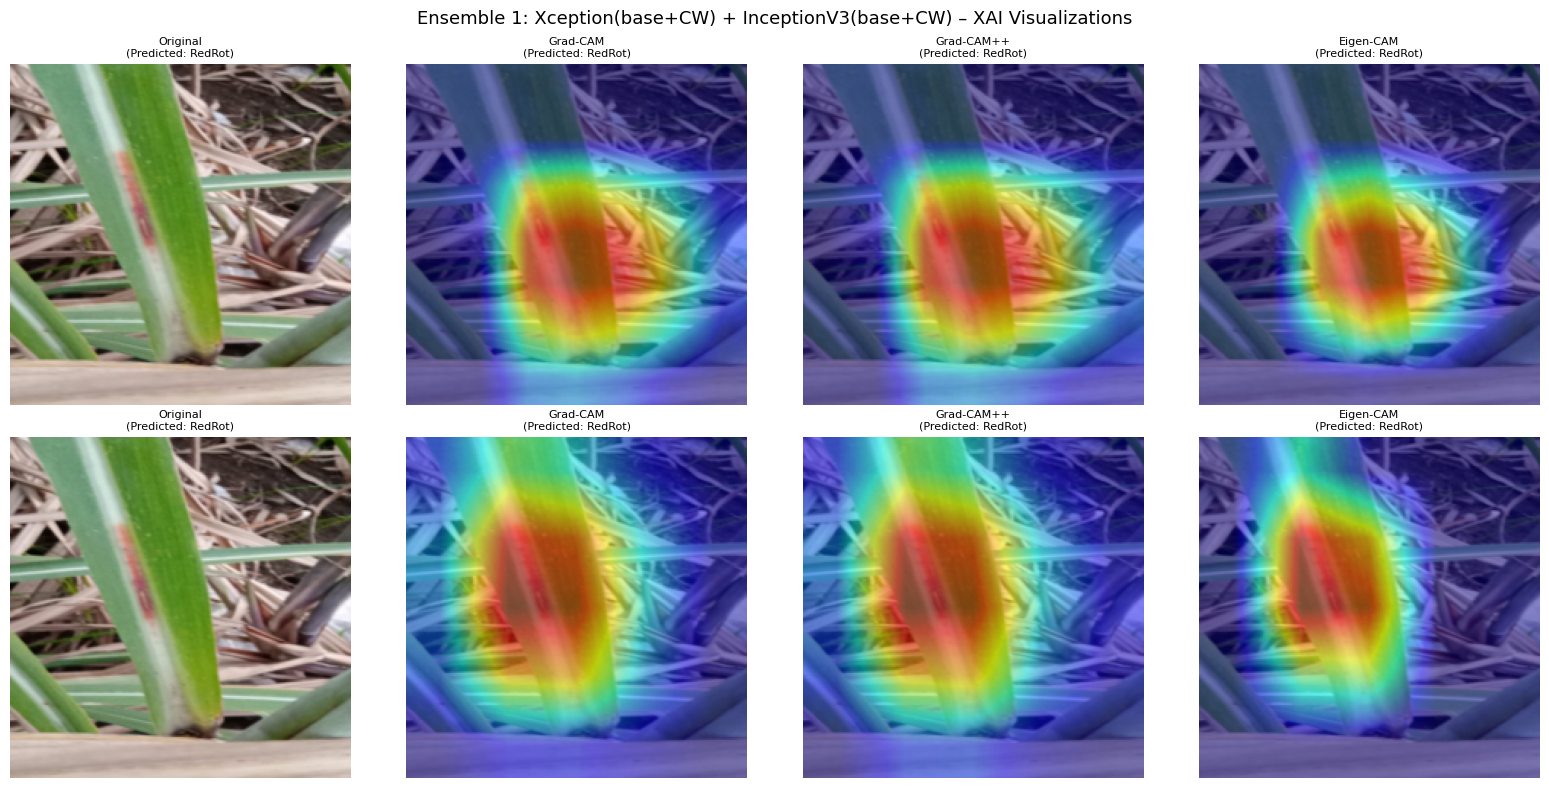

In [13]:
run_xai_ensemble(
    ensemble_model    = ensemble1,
    model_label       = 'Ensemble 1: Xception(base+CW) + InceptionV3(base+CW)',
    target_layers_fn_a = lambda m: [m.act4],           
    target_layers_fn_b = lambda m: [m.Mixed_7c]        
)

---
## Ensemble 2: Xception (CW+SE) + InceptionV3 (CW+SE)

In [14]:
# Load SE attention models
xception_se  = load_xception_attention(num_classes, 'se', PATH_XCEPTION_SE)
inception_se = load_inception_attention(num_classes, 'se', PATH_INCEPTION_SE)

# Create ensemble
ensemble2 = EnsembleModel(xception_se, inception_se, weight_a=0.6, weight_b=0.4).to('cuda')
print("Ensemble 2 ready.")

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 191MB/s] 


Ensemble 2 ready.


### Evaluate — Ensemble 2

In [15]:
evaluate_ensemble(ensemble2, 'Ensemble 2: Xception(CW+SE) + InceptionV3(CW+SE)')


=== Ensemble 2: Xception(CW+SE) + InceptionV3(CW+SE) ===
Accuracy:  96.34%
Precision: 0.9698
Recall:    0.9634
F1 Score:  0.9640


### Save Ensemble 2

In [16]:
save_ensemble_h5(ensemble2, 'ensemble2_xception_inception_se.h5')

Ensemble saved as 'ensemble2_xception_inception_se.h5'


### XAI — Ensemble 2

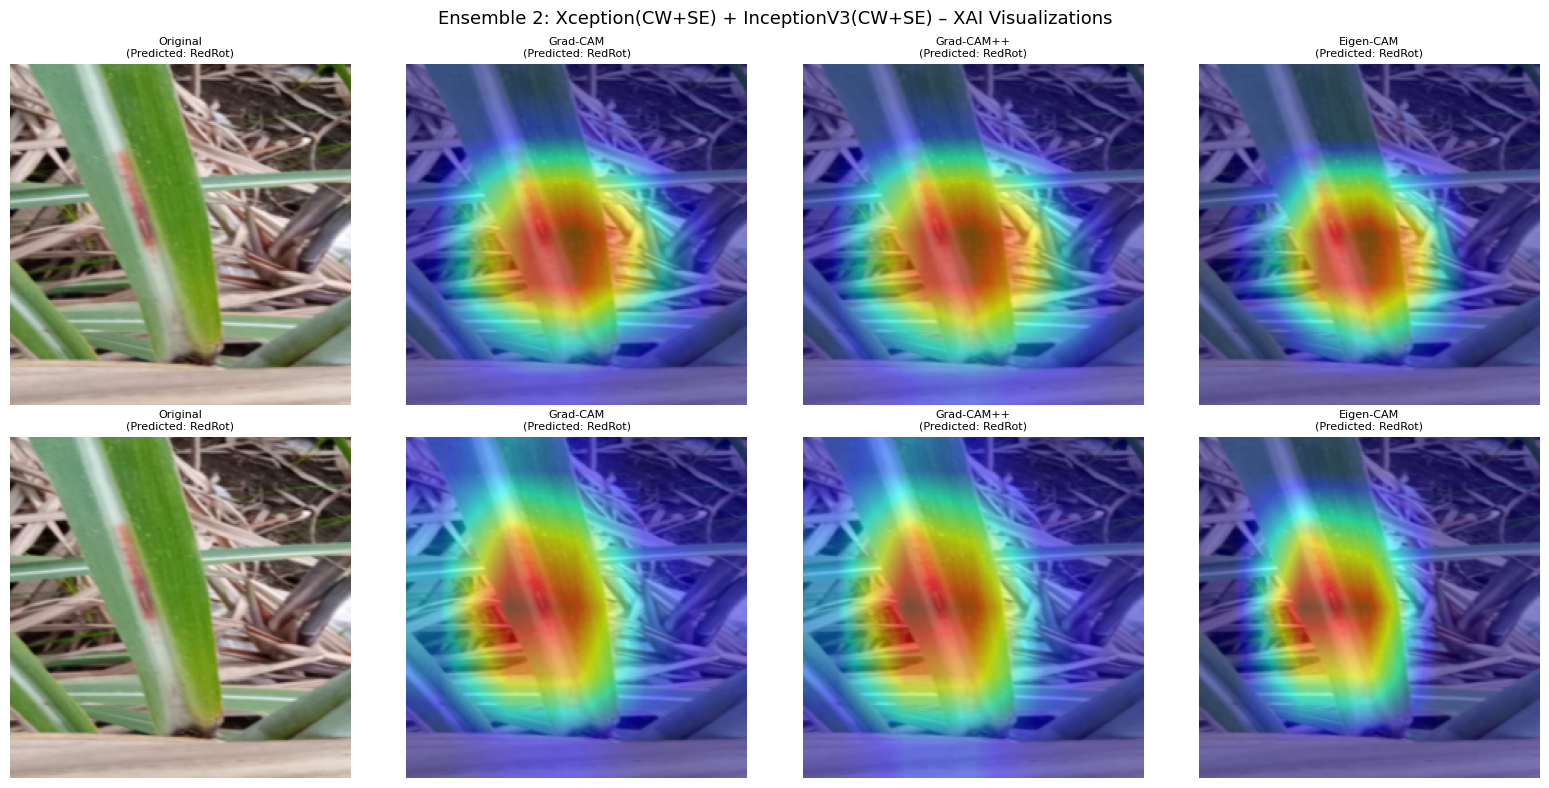

In [17]:
run_xai_ensemble(
    ensemble_model     = ensemble2,
    model_label        = 'Ensemble 2: Xception(CW+SE) + InceptionV3(CW+SE)',
    target_layers_fn_a = lambda m: [m.attention],              # Xception SE block
    target_layers_fn_b = lambda m: [m.inception_blocks[-1]]   # InceptionV3 last block
)

---
## Ensemble 3: Xception (CW+CBAM) + InceptionV3 (CW+CBAM)

In [18]:
# Load CBAM attention models
xception_cbam  = load_xception_attention(num_classes, 'cbam', PATH_XCEPTION_CBAM)
inception_cbam = load_inception_attention(num_classes, 'cbam', PATH_INCEPTION_CBAM)

# Create ensemble
ensemble3 = EnsembleModel(xception_cbam, inception_cbam, weight_a=0.4, weight_b=0.6).to('cuda')
print("Ensemble 3 ready.")

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Ensemble 3 ready.


### Evaluate — Ensemble 3

In [19]:
evaluate_ensemble(ensemble3, 'Ensemble 3: Xception(CW+CBAM) + InceptionV3(CW+CBAM)')


=== Ensemble 3: Xception(CW+CBAM) + InceptionV3(CW+CBAM) ===
Accuracy:  97.20%
Precision: 0.9737
Recall:    0.9720
F1 Score:  0.9722


### Save Ensemble 3

In [20]:
save_ensemble_h5(ensemble3, 'ensemble3_xception_inception_cbam.h5')

Ensemble saved as 'ensemble3_xception_inception_cbam.h5'


### XAI — Ensemble 3

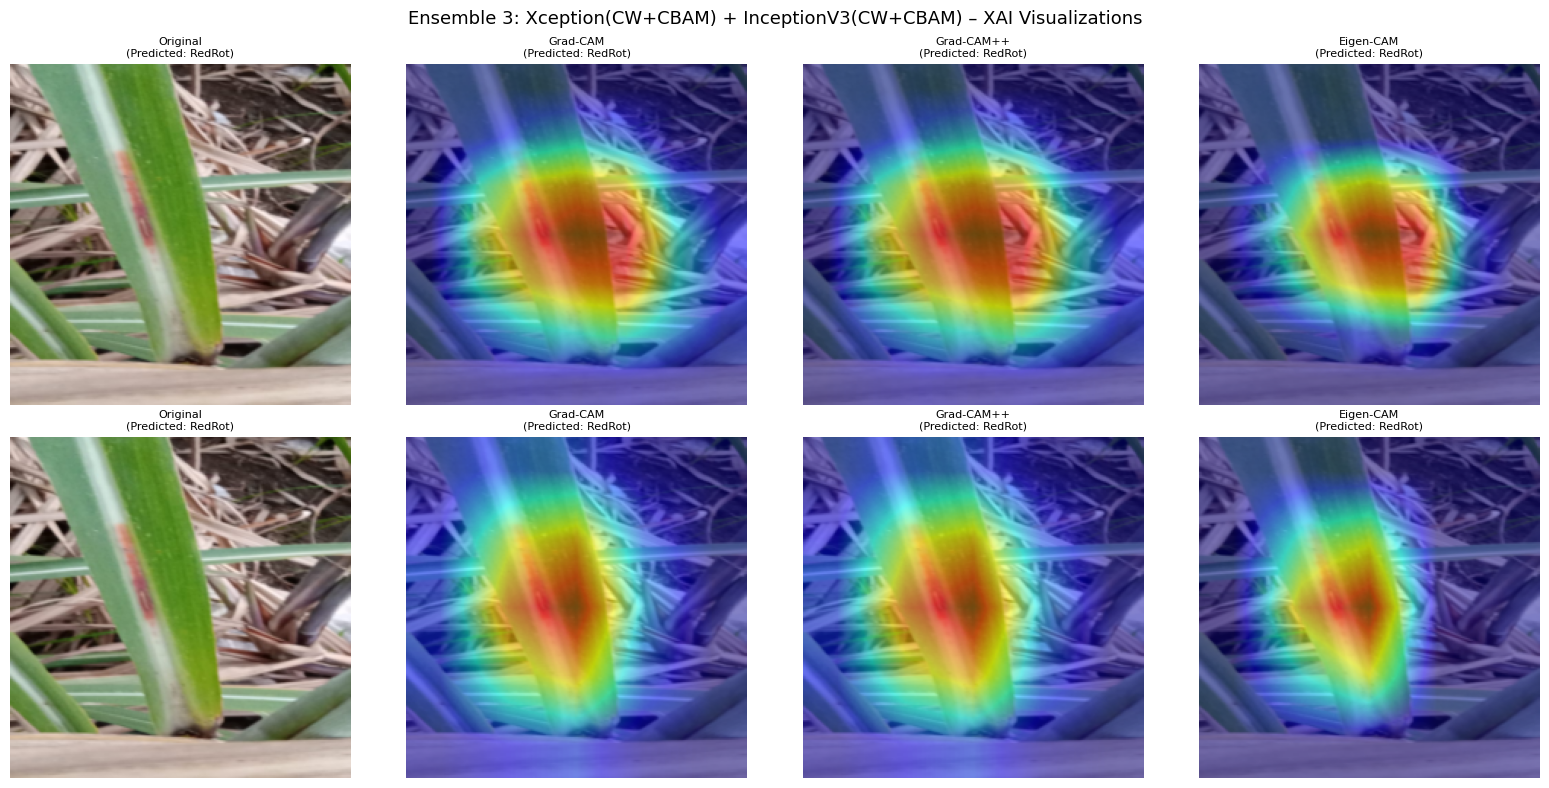

In [21]:
run_xai_ensemble(
    ensemble_model     = ensemble3,
    model_label        = 'Ensemble 3: Xception(CW+CBAM) + InceptionV3(CW+CBAM)',
    target_layers_fn_a = lambda m: [m.attention.spatial_attention],  # Xception CBAM spatial
    target_layers_fn_b = lambda m: [m.inception_blocks[-1]]          # InceptionV3 last block
)

---
## Summary — Compare All 3 Ensembles

In [22]:
print("\n" + "="*60)
print(" ENSEMBLE RESULTS SUMMARY")
print("="*60)
for ens, label in [
    (ensemble1, 'Ensemble 1: Xception(base) + InceptionV3(base)'),
    (ensemble2, 'Ensemble 2: Xception(SE)   + InceptionV3(SE)'),
    (ensemble3, 'Ensemble 3: Xception(CBAM) + InceptionV3(CBAM)'),
]:
    evaluate_ensemble(ens, label)


 ENSEMBLE RESULTS SUMMARY

=== Ensemble 1: Xception(base) + InceptionV3(base) ===
Accuracy:  97.09%
Precision: 0.9721
Recall:    0.9709
F1 Score:  0.9703

=== Ensemble 2: Xception(SE)   + InceptionV3(SE) ===
Accuracy:  96.34%
Precision: 0.9698
Recall:    0.9634
F1 Score:  0.9640

=== Ensemble 3: Xception(CBAM) + InceptionV3(CBAM) ===
Accuracy:  97.20%
Precision: 0.9737
Recall:    0.9720
F1 Score:  0.9722
